Found 6639 images belonging to 3 classes.
Found 1421 images belonging to 3 classes.
Found 1427 images belonging to 3 classes.
Epoch 1/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 944ms/step - accuracy: 0.3604 - loss: 1.1094
Epoch 1: val_accuracy improved from None to 0.35327, saving model to best_efficientnet_thermal_guava.h5


208/208 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.3579 - loss: 1.1074 - val_accuracy: 0.3533 - val_loss: 1.0927 - learning_rate: 1.0000e-04
Epoch 2/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.3626 - loss: 1.1064
Epoch 2: val_accuracy did not improve from 0.35327
208/208 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.3526 - loss: 1.1119 - val_accuracy: 0.3533 - val_loss: 1.0983 - learning_rate: 1.0000e-04
Epoch 3/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3507 - loss: 1.1108
Epoch 3: val_accuracy improved from 0.35327 to 0.36524, saving model to best_efficientnet_thermal_guava.h5



Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
208/208 ━━━━━━━━━━━━━━━━━━━━ 308s 1s/step - accuracy: 0.3574 - loss: 1.1070 - val_accuracy: 0.3652 - val_loss: 1.0927 - learning_rate: 1.0000e-04
Epoch 4/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3518 - loss: 1.1068
Epoch 4: val_accuracy did not improve from 0.36524
208/208 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.3491 - loss: 1.1065 - val_accuracy: 0.3652 - val_loss: 1.0924 - learning_rate: 3.0000e-05
Epoch 5/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3554 - loss: 1.1086
Epoch 5: val_accuracy did not improve from 0.36524
208/208 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.3537 - loss: 1.1097 - val_accuracy: 0.3652 - val_loss: 1.0923 - learning_rate: 3.0000e-05
Epoch 6/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3562 - loss: 1.1089
Epoch 6: val_accuracy did not improve from 0.36524
208/208 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.3552 - loss: 1.1094 


Epoch 7: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.
208/208 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.3464 - loss: 1.1088 - val_accuracy: 0.3758 - val_loss: 1.0923 - learning_rate: 3.0000e-05
Epoch 8/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 936ms/step - accuracy: 0.3638 - loss: 1.1071
Epoch 8: val_accuracy did not improve from 0.37579
208/208 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.3570 - loss: 1.1068 - val_accuracy: 0.3652 - val_loss: 1.0922 - learning_rate: 9.0000e-06
Epoch 9/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 939ms/step - accuracy: 0.3638 - loss: 1.1049
Epoch 9: val_accuracy did not improve from 0.37579

Epoch 9: ReduceLROnPlateau reducing learning rate to 2.6999998226528985e-06.
208/208 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.3588 - loss: 1.1058 - val_accuracy: 0.3652 - val_loss: 1.0922 - learning_rate: 9.0000e-06
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 6.
45/45 ━━━━━━━━━━━━━━━━━━━━ 25s 543ms/step - ac


✅ Test Accuracy: 36.51%
✅ Test Loss: 1.0923
💾 Model saved as 'efficientnetB0_thermal_guava_final.h5'


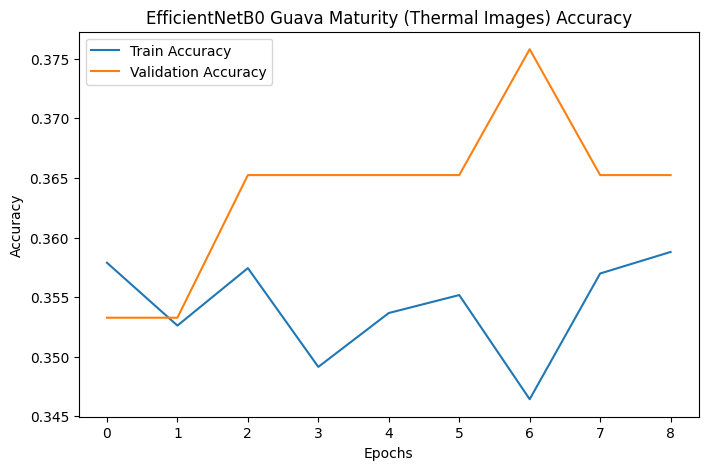

In [1]:
# ============================================================
# 🍃 Guava Maturity Classification using EfficientNetB0 (Thermal Images)
# ============================================================

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import os

# ============================================================
# Dataset Paths (UPDATE these paths to your thermal dataset)
# ============================================================
train_dir = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\Maturity\train test val split  thermal\train"
val_dir   = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\Maturity\train test val split  thermal\val"
test_dir  = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\Maturity\train test val split  thermal\test"

# ============================================================
# Image Parameters
# ============================================================
img_size = (224, 224)
batch_size = 32
epochs = 50

# ============================================================
# Data Generators
# ============================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ============================================================
# Model Definition — EfficientNetB0
# ============================================================
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Custom classifier head
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# Callbacks
# ============================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_efficientnet_thermal_guava.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

# ============================================================
# Training
# ============================================================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

# ============================================================
# Evaluation on Test Set
# ============================================================
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")
print(f"✅ Test Loss: {test_loss:.4f}")

# ============================================================
# Save Final Model
# ============================================================
model.save("efficientnetB0_thermal_guava_final.h5")
print("💾 Model saved as 'efficientnetB0_thermal_guava_final.h5'")

# ============================================================
# Plot Accuracy
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('EfficientNetB0 Guava Maturity (Thermal Images) Accuracy')
plt.show()

In [2]:
# ============================================================
# ✅ Training Accuracy Summary
# ============================================================

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"📊 Final Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"📊 Final Validation Accuracy: {final_val_acc * 100:.2f}%")

📊 Final Training Accuracy: 35.88%
📊 Final Validation Accuracy: 36.52%


In [3]:
# ============================================================
# ✅ Evaluate Model on Test Data
# ============================================================
test_loss, test_acc = model.evaluate(test_gen)
print("\n📊 ================================")
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")
print(f"✅ Test Loss: {test_loss:.4f}")
print("📊 ================================")

45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 511ms/step - accuracy: 0.3651 - loss: 1.0923

📊 ================================
✅ Test Accuracy: 36.51%
✅ Test Loss: 1.0923
📊 ================================


✅ Model loaded successfully!
Found 6639 images belonging to 3 classes.
208/208 ━━━━━━━━━━━━━━━━━━━━ 116s 530ms/step - accuracy: 0.3651 - loss: 1.0922

🎯 Test Accuracy: 36.51%
📉 Test Loss: 1.0922
208/208 ━━━━━━━━━━━━━━━━━━━━ 113s 532ms/step

📊 Classification Report (Test Data):
              precision    recall  f1-score   support

    immature       0.37      1.00      0.53      2424
      mature       0.00      0.00      0.00      2346
 semi_mature       0.00      0.00      0.00      1869

    accuracy                           0.37      6639
   macro avg       0.12      0.33      0.18      6639
weighted avg       0.13      0.37      0.20      6639



c:\Users\cl502_15\AppData\Local\anaconda3\envs\pytorch_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cl502_15\AppData\Local\anaconda3\envs\pytorch_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cl502_15\AppData\Local\anaconda3\envs\pytorch_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

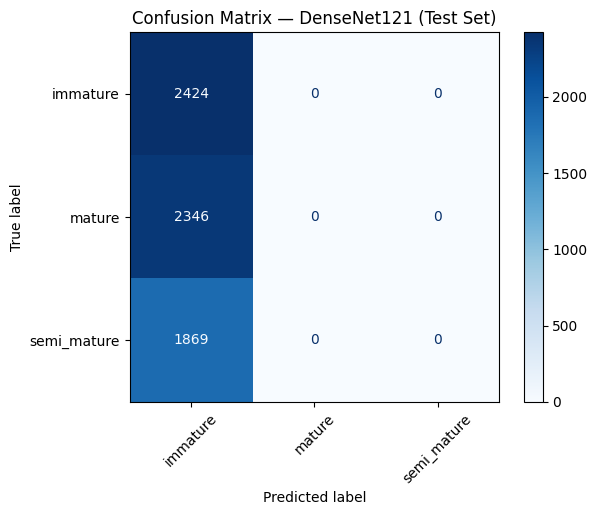

In [2]:
# ============================================================
# 🍃 DenseNet121 — Testing Accuracy Evaluation (Digital Images)
# ============================================================

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ============================================================
# Paths
# ============================================================
test_dir = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\Dataset\Maturity\train test val split  thermal\train"
model_path = r"C:\Users\cl502_15\Downloads\Mtech Major Project\Mtech Major Project\DeepLearningModels\efficientnetB0_thermal_guava_final.h5" # or use "densenet121_digital_guava_final.h5"

# ============================================================
# Load Model
# ============================================================
model = load_model(model_path)
print("✅ Model loaded successfully!")

# ============================================================
# Test Data Generator
# ============================================================
img_size = (224, 224)
batch_size = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ============================================================
# Evaluate on Test Set
# ============================================================
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n🎯 Test Accuracy: {test_acc*100:.2f}%")
print(f"📉 Test Loss: {test_loss:.4f}")

# ============================================================
# Predictions & Detailed Metrics
# ============================================================
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Classification Report
print("\n📊 Classification Report (Test Data):")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix — DenseNet121 (Test Set)")
plt.show()